In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mango dataset.zip to Mango dataset.zip


In [ ]:
import zipfile

zip_path = "Mango dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("mango_dataset")

print("Extracted successfully!")

Extracted successfully!


In [ ]:
import os

print(os.listdir("mango_dataset"))

['UnRipe', 'OverRipe', 'Ripe']


In [ ]:
dataset_path = "mango_dataset"


MANGO RIPENESS DETECTION
1. Train Model
2. Predict Image
Enter choice (1/2): 1
Found 781 images belonging to 3 classes.
Found 194 images belonging to 3 classes.
Detected classes for model: ['OverRipe', 'Ripe', 'UnRipe']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9181 - loss: 0.3534 - val_accuracy: 0.9536 - val_loss: 0.2671
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9744 - loss: 0.1211 - val_accuracy: 0.9536 - val_loss: 0.2368
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9744 - loss: 0.0806 - val_accuracy: 0.9433 - val_loss: 0.2101
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9770 - loss: 0.0880 - val_accuracy: 0.9536 - val_loss: 0.2218
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9795 - loss: 0.0661 - val_accuracy: 0.9485 - val_loss: 0.2780
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9821 - loss: 0.0679 - val_accuracy: 

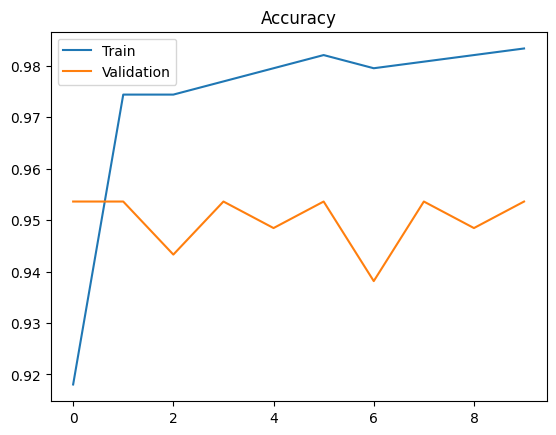

✅ Model trained and saved!


In [ ]:
# ==============================
# MANGO RIPENESS DETECTION PROJECT
# ==============================

# Install (run once in terminal):
# pip install tensorflow matplotlib numpy opencv-python streamlit pillow

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# ==============================
# CONFIG
# ==============================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# Updated to use the correct dataset directory
DATASET_DIR = 'mango_dataset'
MODEL_PATH = "mango_model.h5"

# CLASSES will be dynamically determined from the dataset
CLASSES = []

# ==============================
# 1. TRAIN MODEL
# ==============================
def train_model():
    global CLASSES # Ensure CLASSES variable is updated globally

    # Use a single ImageDataGenerator for both training and validation with validation_split
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=30,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2 # Allocate 20% of data for validation
    )

    train_data = datagen.flow_from_directory(
        DATASET_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training' # Specify training subset
    )

    val_data = datagen.flow_from_directory(
        DATASET_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation' # Specify validation subset
    )

    # Dynamically set CLASSES based on the directory structure found by flow_from_directory
    CLASSES = list(train_data.class_indices.keys())
    print(f"Detected classes for model: {CLASSES}")

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    # Adjust output layer neurons based on the number of detected classes
    output = layers.Dense(len(CLASSES), activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS
    )

    model.save(MODEL_PATH)

    # Plot accuracy
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.legend()
    plt.title("Accuracy")
    plt.show()

    print("✅ Model trained and saved!")

# ==============================
# 2. PREDICT IMAGE
# ==============================
def predict_image(img_path):
    if not os.path.exists(MODEL_PATH):
        print(f"Error: Model file '{MODEL_PATH}' not found. Please train the model first (choose option 1).")
        return
    if not CLASSES:
        print("Error: Classes not defined. Please train the model first to set classes.")
        return

    model = load_model(MODEL_PATH)

    # Check if the provided path is an actual image file
    if not os.path.isfile(img_path):
        print(f"Error: '{img_path}' is not a valid image file path. Please provide a path to an image file (e.g., 'mango_dataset/Ripe/some_mango_image.jpg').")
        return

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    result = CLASSES[np.argmax(prediction)]

    print(f"🥭 Prediction: {result}")

# ==============================
# 3. SIMPLE CLI MENU
# ==============================
if __name__ == "__main__":
    print("\nMANGO RIPENESS DETECTION")
    print("1. Train Model")
    print("2. Predict Image")

    choice = input("Enter choice (1/2): ")

    if choice == '1':
        train_model()

    elif choice == '2':
        path = input("Enter image path: ")
        predict_image(path)

    else:
        print("Invalid choice")

In [ ]:
# ==========================
# PREDICT NEW IMAGE
# ==========================
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_mango(img_path):
    img = image.load_img(img_path, target_size=(224, 224))

    plt.imshow(img)
    plt.axis('off')

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    class_indices = train_data.class_indices
    classes = list(class_indices.keys())

    predicted_class = classes[np.argmax(prediction)]

    print("Predicted Class:", predicted_class)

# Example:
# predict_mango("test.jpg")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving GUTI_138_A.jpg to GUTI_138_A (1).jpg


In [ ]:
predict_image("GUTI_138_A (1).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
🥭 Prediction: OverRipe
